In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [5]:
# build the voabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [76]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [77]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [154]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
C = torch.randn((27,2))

In [10]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([1.4281, 0.8046])

In [11]:
C.shape

torch.Size([27, 2])

In [16]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [17]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [30]:
h = emb.view(-1, 6) @ W1 + b1
h

tensor([[-0.5397, -2.5800,  1.0451,  ...,  1.7388, -0.5512, -1.4318],
        [-1.2935, -3.4992, -3.0069,  ..., -2.0896, -0.0252,  1.8326],
        [ 0.1089,  1.4408, -3.1194,  ...,  2.4146,  2.3534,  0.1078],
        ...,
        [-1.0839, -1.8540, -1.2167,  ...,  0.4382,  4.6354,  0.4959],
        [ 0.4513, -2.9704,  5.1148,  ...,  2.6476, -2.1439, -1.9185],
        [-1.8518, -5.0399,  2.6116,  ..., -0.7854, -3.8311, -0.8570]])

In [35]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
h.shape

torch.Size([32, 100])

In [36]:
logits = h @ W2 + b2

In [37]:
logits.shape

torch.Size([32, 27])

In [38]:
counts = logits.exp()

In [40]:
prob = counts/counts.sum(1, keepdims =True)

In [41]:
prob.shape

torch.Size([32, 27])

In [46]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(inf)

In [44]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [42]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [56]:
# ------------ now made respectable :) ---------------

In [160]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [225]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [226]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [227]:
for p in parameters:
    p.requires_grad = True

In [228]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 **lre

In [229]:
lri = []
lossi = []
stepi = []

In [230]:
for i in range(200000):
  # minibatch construct

  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  # counts = logits.exp()
  # prob = counts / counts.sum(1, keepdims=True)
  # loss = -prob[torch.arange(32), Y].log().mean()
  loss = F.cross_entropy(logits, Ytr[ix]) # this replaces the previous 3 lines.
  #print(loss.item())
  # backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
      p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

# print(loss.item())

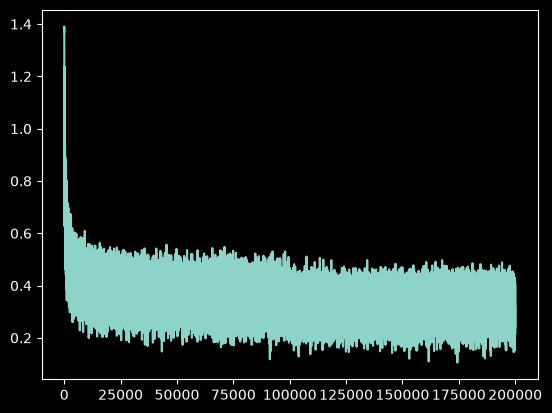

In [231]:
plt.plot(stepi,lossi)

In [232]:
print(loss.item())

2.0947957038879395


In [233]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1231, grad_fn=<NllLossBackward0>)

In [234]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1674, grad_fn=<NllLossBackward0>)

In [ ]:
# training split, dev/valutation split, test split
# 80%, 10%, 10%




